### Mount Drive

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import datetime as datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Load and Inspect Dataset

In [5]:
titanic_train = pd.read_csv("/content/drive/MyDrive/AI ML Materials/Dataset/titanic_train.csv")
titanic_test = pd.read_csv("/content/drive/MyDrive/AI ML Materials/Dataset/titanic_test.csv")

# View first five rows .head()
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# View last five rows .tail()
titanic_train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
# Checking the data dimension
titanic_train.shape

(891, 12)

In [8]:
# Checking the summary statistics
titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# View all the statistics
titanic_train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [10]:
# Checking the data info

titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
# Checking the missing value
titanic_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
# Checking the survivors and non-survivors
titanic_train["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [13]:
# Checking columns of X_test
titanic_test.columns.tolist()

['PassengerId',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [14]:
# Checking missing value for X_test
titanic_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [15]:
# Confirming shape looks right
titanic_test.shape

(418, 11)

###### Having loaded data for inspection, we can see that data for X_train contain 891 columns & 12 rows.

###### There are 177 missing values in Age column, 687 missing in Cabin column(to be dropped), and 2 missing value in Embarked column.

###### For X_test, 418 column, 11 rows. 86 missing value in Age, 1 in Fare, and 327 in Cabin

###### The dataset has 2 target each distributed into 266 and 152

#### Data Preprocessing

In [16]:
### Dropping useless columns first for both train and test
titanic_train.drop(columns=['Name', 'Ticket', 'Cabin'],
              inplace=True, errors='ignore')

titanic_test.drop(columns=['Name', 'Ticket', 'Cabin'],
             inplace=True, errors='ignore')

In [17]:
# Encoding the sex column
le = LabelEncoder()
titanic_train['Sex_encoded'] = le.fit_transform(titanic_train['Sex'])
titanic_train['Embarked_encoded'] = le.fit_transform(titanic_train['Embarked'])

titanic_test['Sex_encoded'] = le.fit_transform(titanic_test['Sex'])
titanic_test['Embarked_encoded'] = le.fit_transform(titanic_test['Embarked'])

In [18]:
### Droping the the originals for both train and test

titanic_train.drop(columns=['Sex', 'Embarked'], inplace=True, errors='ignore')

titanic_test.drop(columns=['Sex', 'Embarked'], inplace=True, errors='ignore')

In [19]:
# Confirming the dropped columns

print(titanic_train.columns.tolist())
print(titanic_test.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded', 'Embarked_encoded']
['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded', 'Embarked_encoded']


In [20]:
# Checking the missing value for Age both train and test

print(titanic_train["Age"].isnull().sum())

print(titanic_test["Age"].isnull().sum())

177
86


In [21]:
# Checking the missing values for Fare both train and test

print(titanic_train["Fare"].isnull().sum())

print(titanic_test["Fare"].isnull().sum())

0
1


In [22]:
# Filling the missing values for Age for both train and test

titanic_train['Age'] = titanic_train['Age'].fillna(titanic_train['Age'].median())
titanic_test['Age'] = titanic_test['Age'].fillna(titanic_train['Age'].median())

# Filling the missing values for Fare for test data
titanic_test['Fare'] = titanic_test['Fare'].fillna(titanic_test['Fare'].median())

### Exploratory Data Analysis(EDA)

In [23]:
# Checking all list columns for both train and test
print(titanic_train.columns.tolist())
titanic_test.columns.tolist()

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded', 'Embarked_encoded']


['PassengerId',
 'Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex_encoded',
 'Embarked_encoded']

#### Pairplot

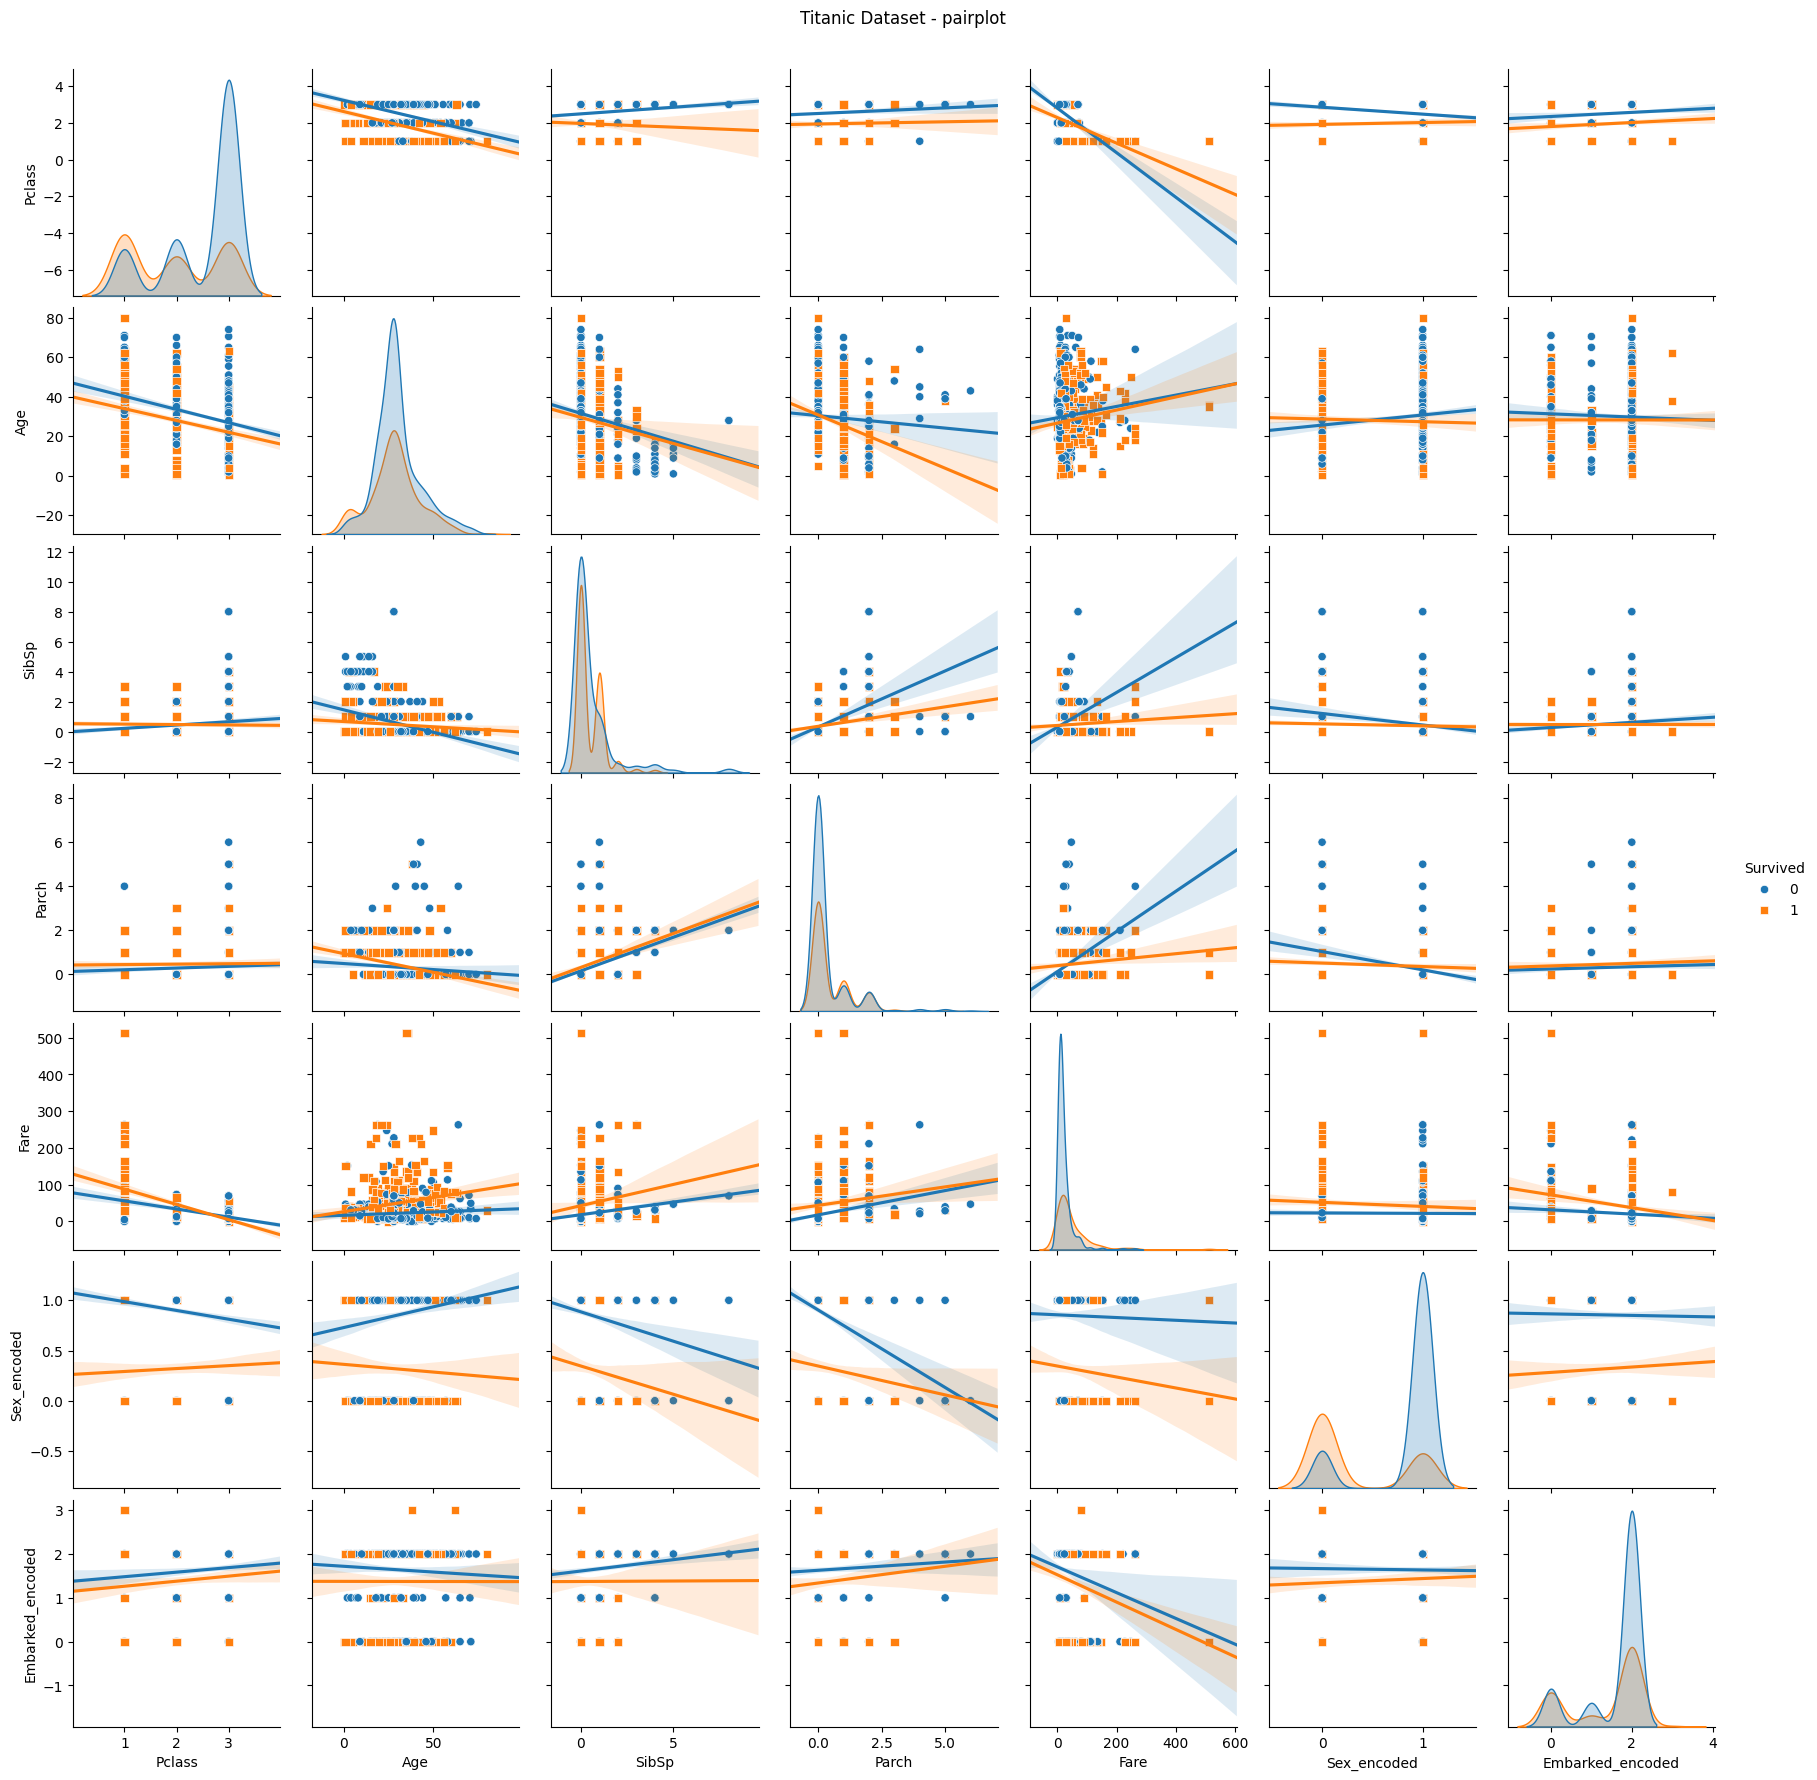

In [24]:
# Let us see the relationship through pairplot
titanic_features = ["Survived", "Pclass", "Age", "SibSp", "Parch",
                    "Fare", "Sex_encoded", "Embarked_encoded"]

df_plot = titanic_train[titanic_features].copy()

g = sns.pairplot(df_plot, hue="Survived", markers=["o", "s"])
g.map_offdiag(sns.regplot, scatter=False, truncate=False)
plt.suptitle("Titanic Dataset - pairplot", y=1.02)
plt.show()

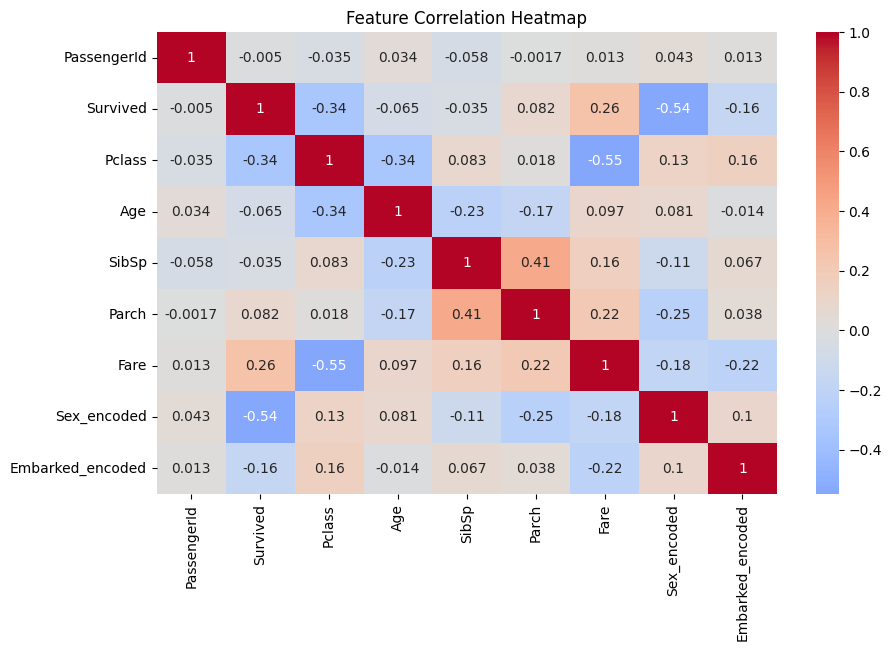

In [25]:
# Let us see the correlation heatmap
plt.figure(figsize=(10, 6))

# Select only numeric columns for correlation
numeric_columns = titanic_train.select_dtypes(include=[np.number])
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

#### Box Plot

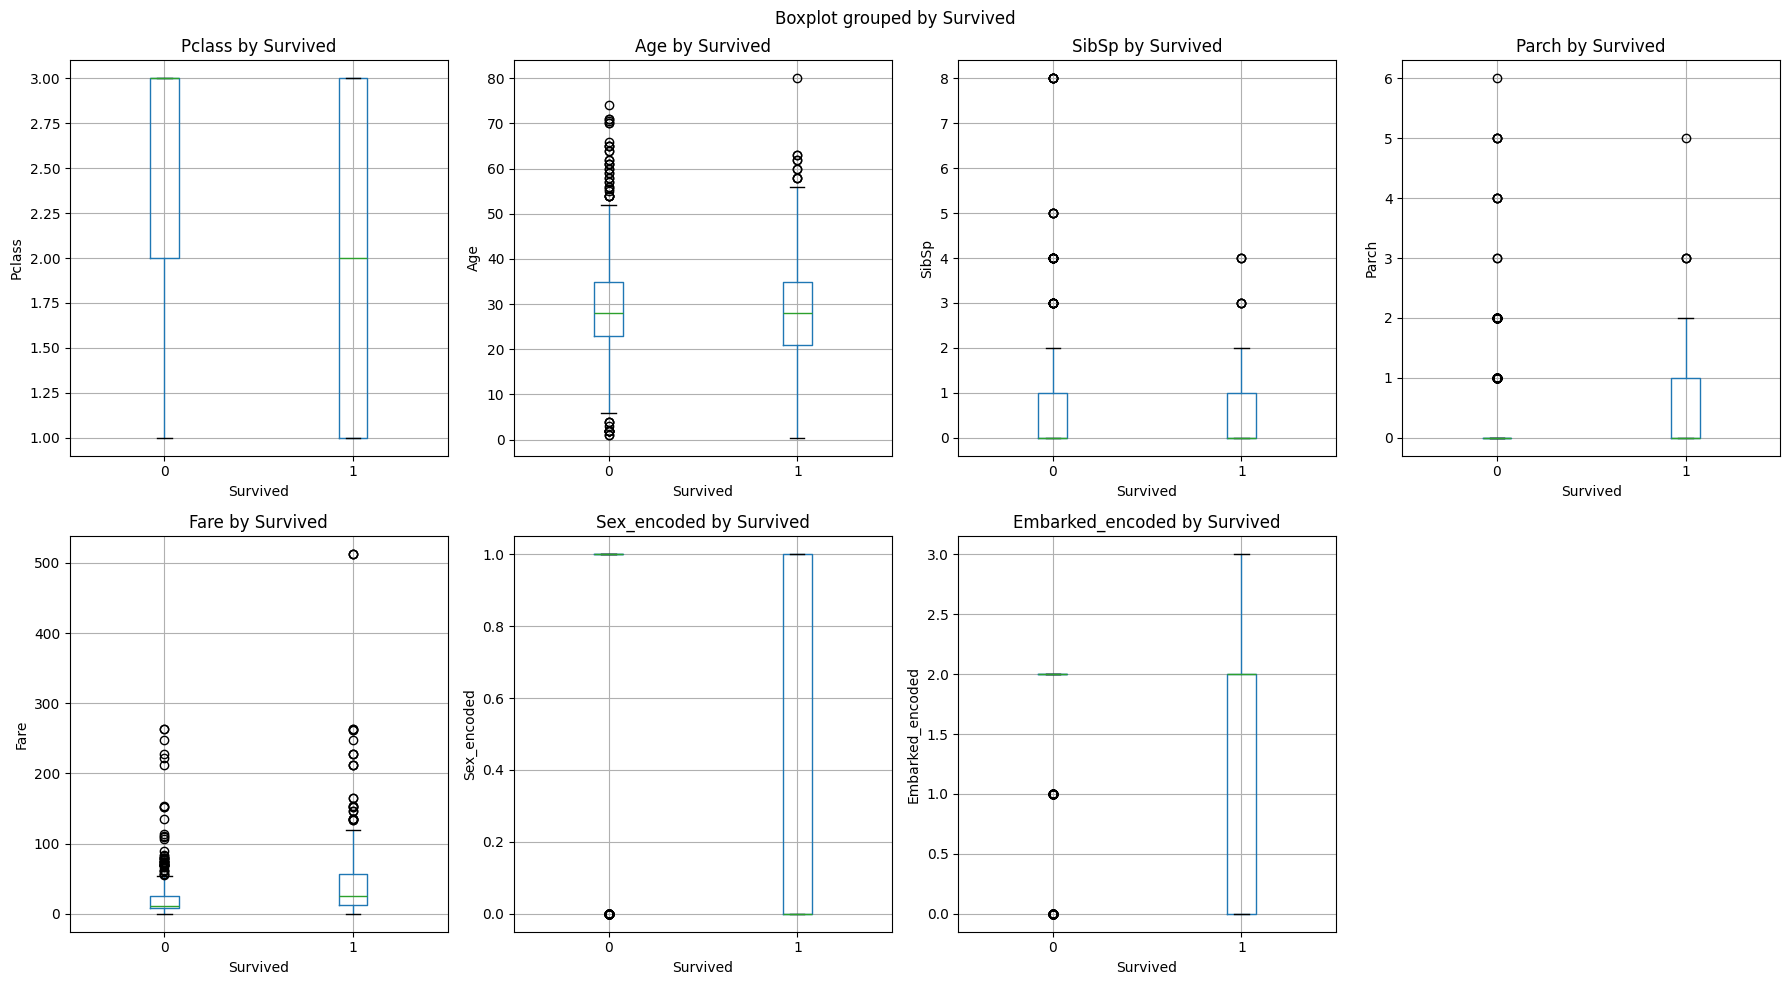

In [26]:
# Let us use it to visualise distribution
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
#features = ['Pclass', 'SibSp', 'Parch', 'Fare',
            #'Sex_encoded', 'Embarked_encoded']
features = [col for col in titanic_train.columns if col not in ['PassengerId', 'Survived']]

for idx, feature in enumerate(features):
    ax = axes[idx // 4, idx % 4]
    titanic_train.boxplot(column=feature, by='Survived', ax=ax)
    ax.set_title(f'{feature} by Survived')
    ax.set_xlabel('Survived')
    ax.set_ylabel(feature)

# Hide the last empty cell
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

### Feature Selection

In [27]:
# First, let us drop PassengerId since they are not real feature
if 'PassengerId' in titanic_train.columns:
    titanic_train = titanic_train.drop('PassengerId', axis=1)

    # Separate features (X) and target (y)
    X = titanic_train.drop('Survived', axis=1)
    y = titanic_train['Survived']

    # Let us see the features
    print("~" * 20)
    print(" Features (X):")
    print("~" * 20)
    print(X.head())

    # Shape of the features
    print("\nShape of X:", X.shape)

    # Let us see the target/label
    print("~" * 20)
    print("Target (y):")
    print("~" * 20)
    print(y.head())

    # Let us see the shape of target
    print("\nShape of y:", y.shape)

    # See unique values
    print("\nUnique titanic_train:", y.unique())



~~~~~~~~~~~~~~~~~~~~
 Features (X):
~~~~~~~~~~~~~~~~~~~~
   Pclass   Age  SibSp  Parch     Fare  Sex_encoded  Embarked_encoded
0       3  22.0      1      0   7.2500            1                 2
1       1  38.0      1      0  71.2833            0                 0
2       3  26.0      0      0   7.9250            0                 2
3       1  35.0      1      0  53.1000            0                 2
4       3  35.0      0      0   8.0500            1                 2

Shape of X: (891, 7)
~~~~~~~~~~~~~~~~~~~~
Target (y):
~~~~~~~~~~~~~~~~~~~~
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

Shape of y: (891,)

Unique titanic_train: [0 1]


In [28]:
# Define features and target
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
            'Sex_encoded', 'Embarked_encoded']

X = titanic_train[features]
y = titanic_train['Survived']

#### Splitting Dataset

In [29]:
# Split the data: 80% training, 20% testing
# Stratify=y ensure each split has the same proportion of each survived
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=234, stratify=y
)

# Check the splits
print("Training set size:", X_train.shape)
print("Training set size:", X_test.shape)
print()

print("~" * 38)
print(" Testting set titanic_train distribution:")
print("~" * 38)
print(y_train.value_counts())

print("~" * 38)
print(" Train set titanic_train distribution:")
print("~" * 38)
print(y_train.value_counts())

Training set size: (712, 7)
Training set size: (179, 7)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Testting set titanic_train distribution:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Survived
0    439
1    273
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Train set titanic_train distribution:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Survived
0    439
1    273
Name: count, dtype: int64


#### Feature Scaling

In [31]:
# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check the scaling
print("~" * 40)
print("Original training data (first 5 rows):")
print("~" * 40)
print(X_train.head())
print()

print("~" * 40 )
print("Scaled training data (first 5 rows):")
print("~" * 40)
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

print("~" * 45)
print("Mean of scaled features (should be close 0):")
print("~" * 45)
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).mean())

print("~" * 45)
print("Std of scaled features (should be close 1):")
print("~" * 45)
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).std())



~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Original training data (first 5 rows):
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
     Pclass   Age  SibSp  Parch      Fare  Sex_encoded  Embarked_encoded
614       3  35.0      0      0    8.0500            1                 2
786       3  18.0      0      0    7.4958            0                 2
128       3  28.0      1      1   22.3583            0                 0
31        1  28.0      1      0  146.5208            0                 0
543       2  32.0      1      0   26.0000            1                 2

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Scaled training data (first 5 rows):
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
     Pclass       Age     SibSp     Parch      Fare  Sex_encoded  \
0  0.828906  0.430897 -0.491555 -0.477640 -0.475442     0.744705   
1  0.828906 -0.871018 -0.491555 -0.477640 -0.485992    -1.342814   
2  0.828906 -0.105186  0.472597  0.796067 -0.203055    -1.342814   
3 -1.555664 -0.105186  0.472597 -0.477640  2.1606

#### Model Training

In [32]:
# Initiate model training
model = LogisticRegression(random_state=234, max_iter=200)

# Train the model
print("Model training in action\n")
model.fit(X_train_scaled, y_train)

Model training in action



LogisticRegression(max_iter=200, random_state=234)

#### Make Predictions

In [34]:
# Making prediction on the X_test split
prediction = model.predict(X_test_scaled)

# let us peak at the predictions
print("\nLogistic Regression predictions (first 10):")
print(prediction[:10])

print("\nActual values (first 10):")
print(y_test.values[:10])


Logistic Regression predictions (first 10):
[1 1 1 0 0 0 0 1 0 0]

Actual values (first 10):
[0 1 1 0 0 0 0 1 0 0]


#### Evaluate Model

In [36]:
# Calculate accuracy of the model
print("~" * 23)
print(" MODEL ACCURACY SCORE")
print("=" * 23)
accuracy = accuracy_score(y_test, prediction)
print(f"{accuracy:.4f} ({accuracy*100:.2f}%)")
print("\n" + "="*60)

# Detailed classification report for the best model
print(f"    DETAILED CLASIFICATION REPORT")
print("="*60)
print(classification_report(y_test, prediction))

# See confusion matrix for the model
print("\n" + "=" * 18)
print(f"  CONFUSION MATRIX")
print("=" * 18)
cm = confusion_matrix(y_test, prediction)
print(cm)


~~~~~~~~~~~~~~~~~~~~~~~
 MODEL ACCURACY SCORE
0.8156 (81.56%)

    DETAILED CLASIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179


  CONFUSION MATRIX
[[98 12]
 [21 48]]


#### Visualise Confusion Matrix

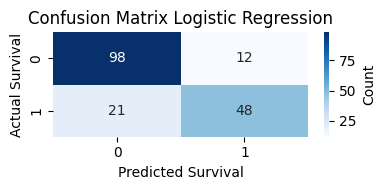

In [38]:
# Visualise confusion matrix for the model
plt.figure(figsize=(4, 2))
cm = confusion_matrix(y_test, prediction)

# Get unique titanic names in the correct order
titanic_survival_names = sorted(y_train.unique())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=titanic_survival_names,
            yticklabels=titanic_survival_names,
            cbar_kws={'label': 'Count'})

plt.ylabel('Actual Survival')
plt.xlabel('Predicted Survival')
plt.title(f'Confusion Matrix Logistic Regression')
plt.tight_layout()
plt.show()


#### Save Model

In [39]:
import joblib

# Save the model
model_filename = 'titanic_survival_model.pkl'
joblib.dump(model, model_filename)
print(f"Model saved as '{model_filename}'")

# Also save the scaler (important for making predictions later)
scaler_filename = 'titanic_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as '{scaler_filename}")

Model saved as 'titanic_survival_model.pkl'
Scaler saved as 'titanic_scaler.pkl


#### Test Loading the Model

In [40]:
# Test loading the model back
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
print("\nModel and scaler loaded successfully!")

# Verify it works by making a test prediction
test_prediction = loaded_model.predict(loaded_scaler.transform(X_train[:5]))
print("\nTest prediction with loaded model:")
print(test_prediction)
print("\nActual values:")
print(y_test[:5].values)


Model and scaler loaded successfully!

Test prediction with loaded model:
[0 1 1 1 0]

Actual values:
[0 1 1 0 0]


#### Making the Real Prediction on Unseen Titanic Dataset

In [50]:
# Dropping passengerId in titanic_test
titanic_test = titanic_test.drop(columns=['PassengerId'], errors='ignore')

# Selecting features
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
            'Sex_encoded', 'Embarked_encoded']

X_titanic_test = titanic_test[features]

# Scaling
X_titanic_test_scaled = scaler.transform(X_titanic_test)

# Make final predictions
final_predictions = model.predict(X_titanic_test_scaled)

# Buidl submission file
submission =pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': final_predictions
})

submission.to_csv("submission.csv", index=False)
print(submission.head(10))
print("Submission saved!")


   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0
Submission saved!
